# Tutorial 02 — CT Windows and Tissue Contrast

**What you will learn:**
- Why the same CT scan can look completely different depending on display settings
- What a "window" is and how to choose one for different tissues
- How to see lungs, soft tissue, and bone in the same scan
- How HU statistics differ between body regions

**No GPU needed.** This notebook uses pre-generated CT scans from `outputs/`.

---
> **Safety reminder:** All images are fully synthetic — generated by AI, not from any real patient.

## The Problem: Too Much Data for One Screen

A CT scan contains values from roughly **−1000 to +3000 HU** — that is a range of ~4000 values. But your monitor can only display **256 shades of grey**.

If you tried to map all 4000 values onto 256 shades, the differences between soft tissue types (which span only ~100 HU) would become invisible.

**The solution is a window** — a chosen range of HU values that gets stretched to fill all 256 shades:
- Everything below the window = solid **black**
- Everything above the window = solid **white**
- Everything inside the window = displayed with full contrast

A window is defined by two numbers:
- **Centre (Level):** The HU value at the middle of the window
- **Width:** How many HU values fit inside the window

| Window name | Centre (HU) | Width (HU) | Best for |
|---|---:|---:|---|
| Soft tissue | 40 | 400 | Organs, tumors, muscles |
| Lung | −600 | 1500 | Airways, lung parenchyma |
| Bone | 400 | 1800 | Skeleton, vertebrae, ribs |
| Brain | 40 | 80 | Brain tissue differentiation |

Radiologists switch between these constantly when reading a scan.

In [2]:
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve()
for _ in range(6):
    if (PROJECT_ROOT / 'outputs').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

%matplotlib inline
plt.rcParams.update({'figure.facecolor': '#0d1117', 'axes.facecolor': '#0d1117',
                     'text.color': 'white', 'axes.labelcolor': '#aaa',
                     'xtick.color': '#aaa', 'ytick.color': '#aaa'})

def apply_window(data, centre, width):
    """Map HU values to [0, 1] using a window/level display."""
    lo = centre - width / 2
    hi = centre + width / 2
    return np.clip((data - lo) / (hi - lo), 0.0, 1.0)

# Window presets (centre, width)
WINDOWS = {
    'Soft tissue\n(C=40, W=400)':  (40,  400),
    'Lung\n(C=−600, W=1500)':      (-600, 1500),
    'Bone\n(C=400, W=1800)':        (400, 1800),
}

print('Setup complete.')

Setup complete.


In [3]:
# Load chest CT (has heart, lungs, ribs — perfect for showing all three windows)
chest_path = PROJECT_ROOT / 'outputs/maisi2_showcase_ct_chest_cardio_lung/visuals/sample_001_seed71001/ct_seed71001_image.nii.gz'
chest = nib.load(str(chest_path)).get_fdata(dtype=np.float32)

# Pick a good axial slice that shows heart + lungs + ribs clearly
z = chest.shape[2] // 2
axial = chest[:, :, z]   # one 2D slice

print(f'Chest CT shape: {chest.shape}  |  Selected axial slice: z={z}')

Chest CT shape: (256, 256, 128)  |  Selected axial slice: z=64


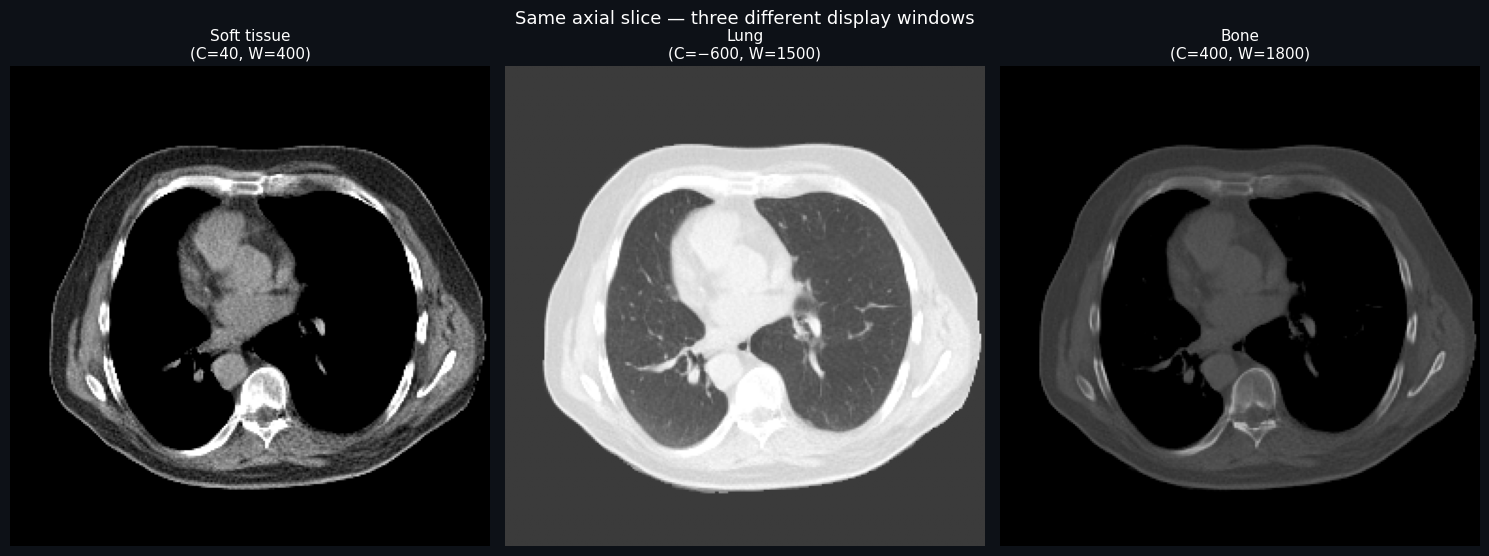

Same CT, same slice — but each window reveals different anatomy.


In [4]:
# ── Same slice, three different windows ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

for ax, (name, (centre, width)) in zip(axes, WINDOWS.items()):
    windowed = apply_window(axial, centre, width)
    ax.imshow(np.rot90(windowed), cmap='gray', vmin=0, vmax=1, aspect='equal')
    ax.set_title(name, fontsize=11)
    ax.axis('off')

fig.suptitle('Same axial slice — three different display windows', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures/tut02_three_windows.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Same CT, same slice — but each window reveals different anatomy.')

### What changed?

**Soft tissue window** (centre=40, width=400):
- Heart and great vessels are visible as different shades of grey
- Ribs appear very bright (above the window → clipped to white)
- Lung tissue is completely black (below the window → clipped)

**Lung window** (centre=−600, width=1500):
- Lung detail appears — you can see the lung parenchyma and airway branching patterns
- Soft tissue all collapses to bright grey (above the window)

**Bone window** (centre=400, width=1800):
- Rib cortex is crisp and white; trabecular detail visible
- Everything else (soft tissue, lung) becomes uniform dark grey

**No window is better than another** — they reveal different things. A clinical CT report requires reviewing all windows.

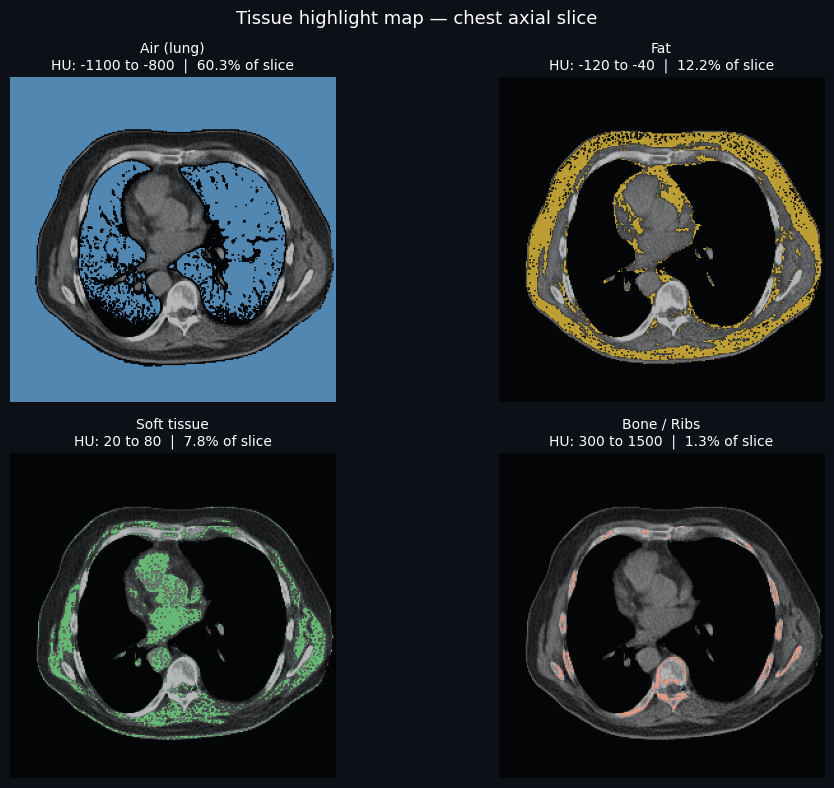

Each colour highlights voxels in the given HU range.


In [5]:
# ── What tissues look like at different HU values ─────────────────────────
#
# Let's find some specific tissue examples in the scan

tissue_ranges = {
    'Air (lung)':        (-1100, -800),
    'Fat':               (-120,  -40),
    'Soft tissue':       (  20,   80),
    'Bone / Ribs':       ( 300, 1500),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
soft_windowed = apply_window(axial, 40, 400)

colors = ['#74c0fc', '#ffd43b', '#69db7c', '#f78c6b']
for ax, (tissue, (lo, hi)), color in zip(axes.ravel(), tissue_ranges.items(), colors):
    # show soft-tissue background
    ax.imshow(np.rot90(soft_windowed), cmap='gray', vmin=0, vmax=1, aspect='equal', alpha=0.7)
    # highlight the tissue of interest
    mask = (axial >= lo) & (axial <= hi)
    highlight = np.zeros((*axial.shape, 4), dtype=np.float32)
    highlight[mask, :3] = plt.matplotlib.colors.to_rgb(color)
    highlight[mask, 3] = 0.7
    ax.imshow(np.rot90(highlight), aspect='equal')
    pct = mask.mean() * 100
    ax.set_title(f'{tissue}\nHU: {lo} to {hi}  |  {pct:.1f}% of slice', fontsize=10)
    ax.axis('off')

fig.suptitle('Tissue highlight map — chest axial slice', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures/tut02_tissue_highlights.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Each colour highlights voxels in the given HU range.')

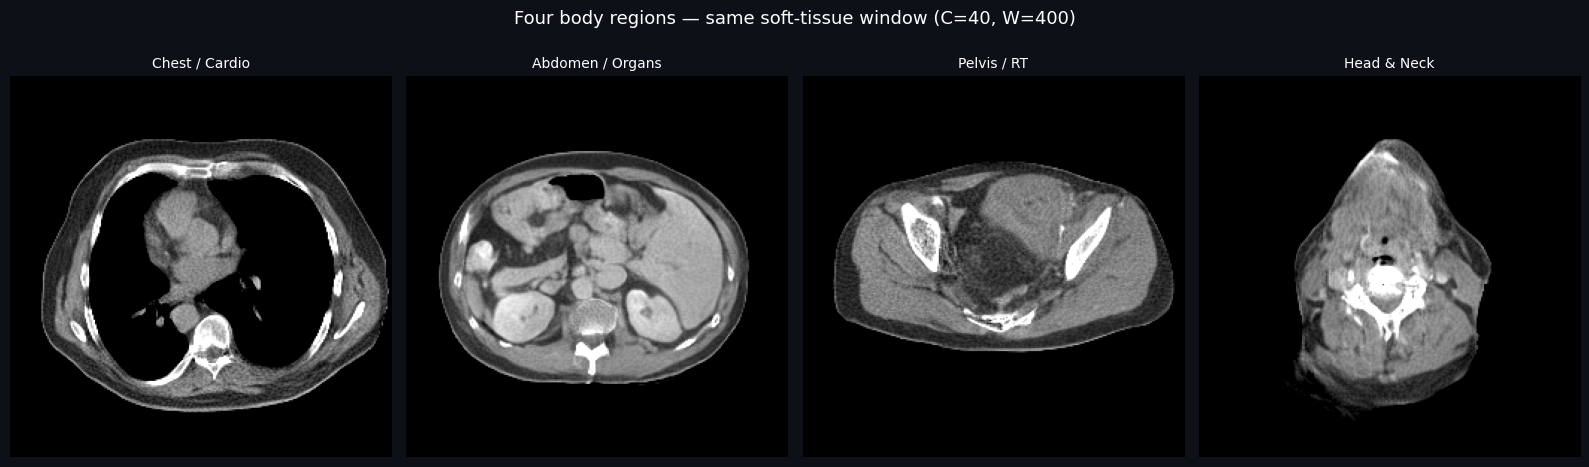

Notice how different each region looks even with identical window settings.


In [6]:
# ── Compare three body regions in soft-tissue window ──────────────────────
#
# Different body regions look completely different even with the same window.

regions = [
    ('Chest / Cardio', 'maisi2_showcase_ct_chest_cardio_lung/visuals/sample_001_seed71001/ct_seed71001_image.nii.gz'),
    ('Abdomen / Organs', 'maisi2_showcase_ct_abdomen_organs_tumor/visuals/sample_001_seed72001/ct_seed72001_image.nii.gz'),
    ('Pelvis / RT',    'maisi2_showcase_ct_pelvis_rt/visuals/sample_001_seed73001/ct_seed73001_image.nii.gz'),
    ('Head & Neck',    'maisi2_showcase_ct_head_neck/visuals/sample_001_seed74001/ct_seed74001_image.nii.gz'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (name, rel_path) in zip(axes, regions):
    vol = nib.load(str(PROJECT_ROOT / 'outputs' / rel_path)).get_fdata(dtype=np.float32)
    z = vol.shape[2] // 2
    slc = apply_window(vol[:, :, z], 40, 400)
    ax.imshow(np.rot90(slc), cmap='gray', vmin=0, vmax=1, aspect='equal')
    ax.set_title(name, fontsize=10)
    ax.axis('off')

fig.suptitle('Four body regions — same soft-tissue window (C=40, W=400)', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures/tut02_body_regions_comparison.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Notice how different each region looks even with identical window settings.')

In [7]:
# ── HU statistics per body region ─────────────────────────────────────────
#
# Different body regions have different HU 'fingerprints'.

print(f'{"Region":<22} {"Min":>6} {"Max":>6} {"Mean":>7} {"Std":>7}  Air%  Soft%  Bone%')
print('─' * 75)

for name, rel_path in regions:
    vol = nib.load(str(PROJECT_ROOT / 'outputs' / rel_path)).get_fdata(dtype=np.float32)
    air_pct   = (vol < -500).mean() * 100
    soft_pct  = ((vol >= -100) & (vol < 200)).mean() * 100
    bone_pct  = (vol >= 200).mean() * 100
    print(f'{name:<22} {vol.min():>6.0f} {vol.max():>6.0f} {vol.mean():>7.1f} {vol.std():>7.1f}  {air_pct:4.1f}%  {soft_pct:4.1f}%  {bone_pct:4.1f}%')

print()
print('The chest has the highest air% (lungs). The head has the highest bone% (skull).')

Region                    Min    Max    Mean     Std  Air%  Soft%  Bone%
───────────────────────────────────────────────────────────────────────────
Chest / Cardio          -1000   1000  -560.4   491.2  58.2%  32.8%   2.3%
Abdomen / Organs        -1000   1000  -654.6   483.6  67.3%  29.3%   1.3%
Pelvis / RT             -1000   1000  -652.6   484.1  65.7%  29.0%   2.0%
Head & Neck             -1000   1000  -586.7   514.4  61.6%  30.9%   4.0%

The chest has the highest air% (lungs). The head has the highest bone% (skull).


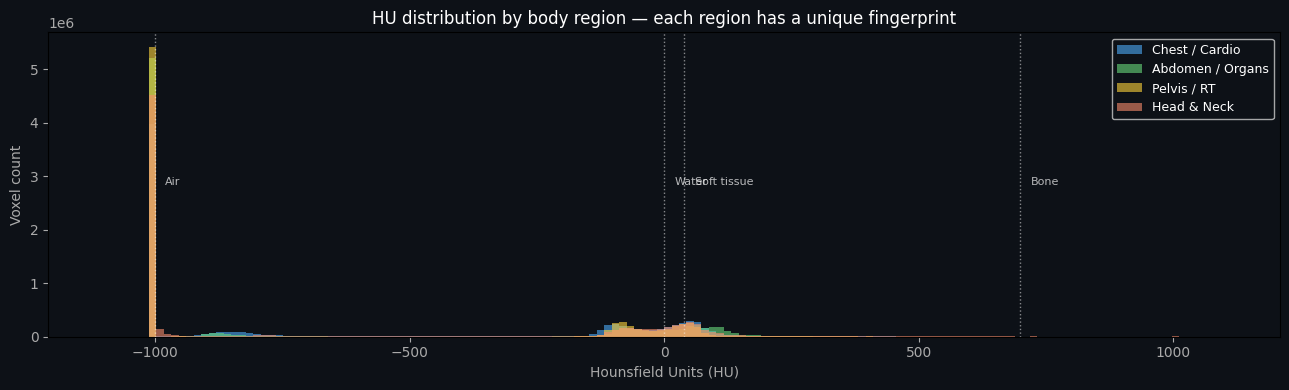

: 

In [ ]:
# ── HU histograms for all body regions ────────────────────────────────────

colors_region = ['#4dabf7', '#69db7c', '#ffd43b', '#f78c6b']
fig, ax = plt.subplots(figsize=(13, 4))

for (name, rel_path), color in zip(regions, colors_region):
    vol = nib.load(str(PROJECT_ROOT / 'outputs' / rel_path)).get_fdata(dtype=np.float32)
    ax.hist(vol.ravel(), bins=150, range=(-1100, 1100), alpha=0.6, color=color, label=name, edgecolor='none')

for hu, label in [(-1000,'Air'), (0,'Water'), (40,'Soft tissue'), (700,'Bone')]:
    ax.axvline(hu, color='white', linestyle=':', linewidth=1, alpha=0.5)
    ax.text(hu + 20, ax.get_ylim()[1] * 0.5, label, color='white', fontsize=8, alpha=0.7)

ax.set_xlabel('Hounsfield Units (HU)')
ax.set_ylabel('Voxel count')
ax.set_title('HU distribution by body region — each region has a unique fingerprint')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures/tut02_hu_histograms.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## Summary

| Concept | Key takeaway |
|---|---|
| Window | Maps a chosen HU range to the full grey scale |
| Soft tissue window | Best for organs, tumors, muscles (C=40, W=400) |
| Lung window | Best for airways and lung parenchyma (C=−600, W=1500) |
| Bone window | Best for ribs, spine, cortical structure (C=400, W=1800) |
| Body region fingerprint | Each region has a distinctive HU distribution |

### Why does this matter for AI?

When you train a CT segmentation model, the choice of window during preprocessing is a critical hyperparameter. If you train a lung nodule detector using soft-tissue window preprocessing, it may never see the fine airway detail it needs. Many published models specify their exact window settings in the methods section.

## What's next?

Next: **Tutorial 03** — segmentation masks (the label files that tell you which voxel belongs to which organ).